# **Exploratory Data Analysis of the Netflix Prize Dataset**
## Objective

The objective of this analysis is to understand user behavior, content popularity, rating patterns, and data sparsity characteristics within the Netflix Prize Dataset.

This exploratory analysis serves as the foundation for developing recommendation systems capable of generating personalized movie recommendations.

# 1. Dataset Overview


In [1]:
import numpy as np
import pandas as pd
from tqdm import tqdm


In [2]:
df = pd.read_csv("../data/processed/netflix_1000_movies.csv")

In [3]:
print("Rows:", len(df))
print("Users:", df.user_id.nunique())
print("Movies:", df.movie_id.nunique())

Rows: 5010199
Users: 404555
Movies: 1000


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5010199 entries, 0 to 5010198
Data columns (total 4 columns):
 #   Column    Dtype 
---  ------    ----- 
 0   user_id   int64 
 1   movie_id  int64 
 2   rating    int64 
 3   date      object
dtypes: int64(3), object(1)
memory usage: 152.9+ MB


# 2. Rating Distribution Analysis

We first analyze how users assign ratings to movies. Understanding rating behavior helps identify user sentiment and potential biases in the dataset.


rating
1     220893
2     489159
3    1431766
4    1733768
5    1134613
Name: count, dtype: int64


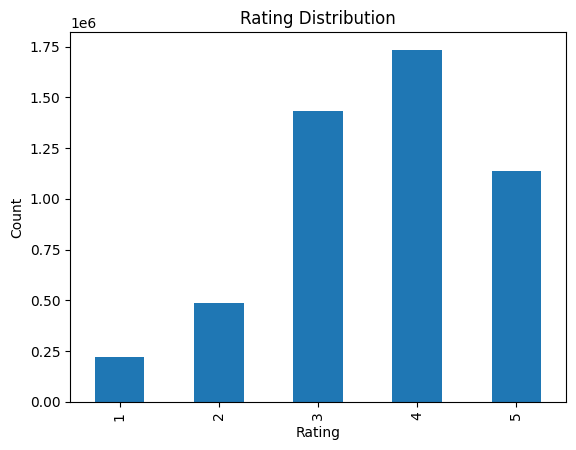

In [5]:
import matplotlib.pyplot as plt

rating_counts = (df.rating.value_counts().sort_index())

print(rating_counts)

rating_counts.plot(kind="bar")
plt.title("Rating Distribution")
plt.xlabel("Rating")
plt.ylabel("Count")
plt.show()

The rating distribution is positively skewed, with ratings 3, 4, and 5 accounting for the majority of user feedback. Rating 4 is the most frequently assigned score, indicating that users generally provide favorable evaluations of watched content. Low ratings (1 and 2) are comparatively rare, suggesting the presence of positive feedback bias. From a business perspective, this indicates strong user satisfaction and effective content discovery. From a technical perspective, the imbalance in rating frequencies may bias recommendation models toward predicting higher ratings, making accurate ranking among highly rated items a more challenging task.

# 3. User Activity Analysis

In [6]:
user_activity = (df.groupby("user_id").size())

user_activity.describe()

count    404555.000000
mean         12.384469
std          16.813723
min           1.000000
25%           2.000000
50%           6.000000
75%          16.000000
max         993.000000
dtype: float64

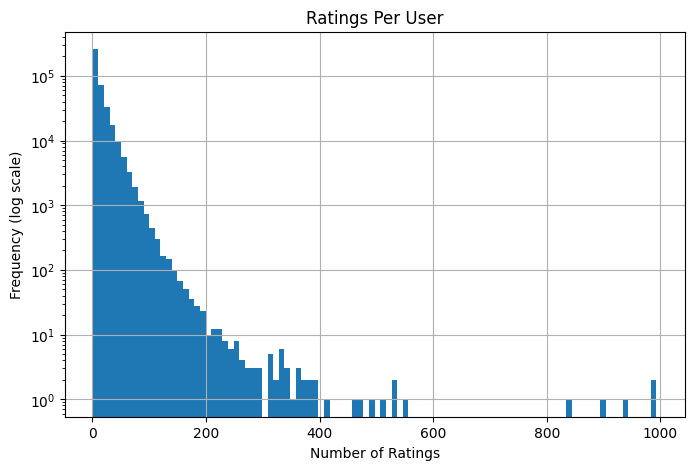

In [15]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
user_activity.hist(bins=100,log=True)
plt.title("Ratings Per User")
plt.xlabel("Number of Ratings")
plt.ylabel("Frequency (log scale)")
plt.show()

In [8]:
user_activity.sort_values(ascending=False).head(10)

user_id
305344     993
387418     984
2439493    935
1664010    897
2118461    836
1314869    548
1461435    536
1639792    529
1932594    507
2606799    488
dtype: int64

User activity follows a highly skewed long-tail distribution. While the average user in the sampled dataset provided approximately 12.4 ratings, the median user provided only 6 ratings. A small subset of highly active users contributed significantly more ratings, with the most active user rating 993 movies. This long-tail behavior indicates that most users provide limited feedback, creating challenges for personalization and user similarity estimation. From a business perspective, understanding and engaging highly active users is valuable because they contribute a large portion of interaction data. The platform may benefit from encouraging greater user participation to improve personalization. From a technical perspective, sparse user profiles introduce cold-start challenges and reduce the effectiveness of user-based collaborative filtering methods, motivating the use of item-based and latent-factor recommendation approaches.

# 4. Content Popularity Analysis

In [9]:
movie_popularity = (df.groupby("movie_id").size())

movie_popularity.describe()

count      1000.000000
mean       5010.199000
std       14518.090683
min          43.000000
25%         194.000000
50%         576.000000
75%        2634.500000
max      154832.000000
dtype: float64

In [10]:
movie_popularity.sort_values(ascending=False).head(10)

movie_id
571    154832
30     118413
457    116762
886    108606
758    104362
607    100248
313     99812
191     98720
175     90450
483     90010
dtype: int64

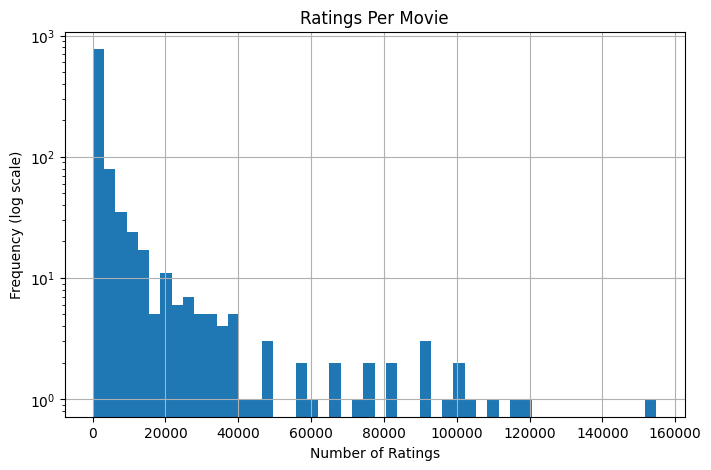

In [16]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

movie_popularity.hist(bins=50,log=True)

plt.title("Ratings Per Movie")
plt.xlabel("Number of Ratings")
plt.ylabel("Frequency (log scale)")
plt.show()

Movie popularity exhibits a highly skewed long-tail distribution. While the median movie received approximately 472 ratings, the most popular movie accumulated over 118,000 ratings. The large gap between the mean and median number of ratings indicates that user interactions are concentrated around a small set of highly popular titles. From a business perspective, this highlights the importance of content discovery mechanisms that expose users to less popular but relevant content. From a technical perspective, popularity bias may cause recommendation models to over-recommend blockbuster movies, reducing recommendation diversity and personalization quality.

# 5. Data Sparsity Analysis

In [12]:
num_users = df.user_id.nunique()
num_movies = df.movie_id.nunique()

possible_ratings = num_users * num_movies
actual_ratings = len(df)

sparsity = 1 - (actual_ratings / possible_ratings)

print("Users:", num_users)
print("Movies:", num_movies)
print("Actual Ratings:", actual_ratings)
print("Possible Ratings:", possible_ratings)
print("Sparsity:", sparsity)

Users: 404555
Movies: 1000
Actual Ratings: 5010199
Possible Ratings: 404555000
Sparsity: 0.9876155306447826


In [13]:
print("\n===== EDA SUMMARY =====")

print(f"Users: {df.user_id.nunique():,}")
print(f"Movies: {df.movie_id.nunique():,}")
print(f"Ratings: {len(df):,}")
print(f"Sparsity: {sparsity:.2%}")


===== EDA SUMMARY =====
Users: 404,555
Movies: 1,000
Ratings: 5,010,199
Sparsity: 98.76%


The sampled dataset exhibits extreme sparsity, with 5,010,199 observed ratings out of more than 404.5 million possible user–movie interactions, resulting in a sparsity level of approximately 98.76%. This indicates that users have interacted with only a very small fraction of available content. From a business perspective, such sparsity highlights the importance of recommendation systems for content discovery and user engagement. From a technical perspective, the large proportion of missing interactions makes traditional predictive approaches unsuitable and motivates the use of collaborative filtering and matrix factorization techniques capable of learning from sparse data.

## Business and Technical Implications

The EDA reveals several characteristics that make recommendation systems necessary for this dataset:

- Users interact with only a small fraction of available content.
- User engagement follows a long-tail distribution.
- Movie popularity is highly concentrated.
- The dataset exhibits extreme sparsity.
- Recommendation models must balance personalization and popularity.

These findings motivate the use of collaborative filtering and matrix factorization techniques explored in subsequent sections of the project.

# 6. Key Findings and Insights


## Insight 1: User Engagement Follows a Long-Tail Distribution

User activity is highly uneven across the platform. While the average user provided approximately 12 ratings, the median user provided only 6 ratings. A small group of highly active users contributed hundreds of ratings, with the most active user providing nearly 1,000 ratings.

**Business Implication:** Highly engaged users contribute a significant portion of interaction data and play an important role in improving recommendation quality.

**Technical Implication:** Sparse user histories create cold-start challenges and make it difficult to accurately model user preferences.

---

## Insight 2: Movie Popularity Is Highly Concentrated

Movie popularity exhibits a strong long-tail distribution. While the median movie received only 576 ratings, the most popular movie received more than 154,000 ratings.

**Business Implication:** A small number of blockbuster titles dominate user attention, making content discovery an important business objective.

**Technical Implication:** Recommendation systems may become biased toward popular movies and fail to surface niche content.

---

## Insight 3: The Dataset Is Extremely Sparse

Out of more than 404 million possible user-movie interactions, only approximately 5 million ratings were observed, resulting in a sparsity level of 98.76%.

**Business Implication:** Users interact with only a small fraction of available content, making personalized recommendations essential.

**Technical Implication:** Traditional machine learning approaches struggle with such sparse data, motivating the use of collaborative filtering and matrix factorization techniques.

---

## Insight 4: Users Tend to Provide Positive Ratings

The rating distribution is skewed toward higher ratings, with ratings of 3, 4, and 5 occurring much more frequently than lower ratings.

**Business Implication:** Users generally consume content they expect to enjoy, indicating effective content selection behavior.

**Technical Implication:** Recommendation models may develop a positive-rating bias and require careful evaluation to avoid overestimating user satisfaction.

---

## Insight 5: Popularity Bias and Sparsity Create Recommendation Challenges

The combination of highly sparse user profiles and concentrated movie popularity creates a difficult recommendation problem. Models must balance recommending popular movies with discovering less-known but relevant content.

**Business Implication:** Effective recommendation systems can significantly improve user engagement by helping users discover content they may otherwise never encounter.

**Technical Implication:** Recommendation quality should be evaluated using both rating prediction metrics (RMSE) and ranking metrics (MAP@10) to ensure recommendations are both accurate and useful.


# EDA Conclusion

The Netflix Prize Dataset exhibits several characteristics commonly observed in large-scale recommendation systems, including highly skewed user activity, concentrated content popularity, positive rating bias, and extreme sparsity.

These findings indicate that users interact with only a small fraction of available content, making personalized recommendation systems essential for content discovery. Furthermore, the observed sparsity and popularity imbalance motivate the use of collaborative filtering and matrix factorization techniques, which are explored in the subsequent modeling phase of this project.
